In [762]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from types import SimpleNamespace

In [763]:
DATA_DIR = "./dataset"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# RNN forecasting hyper-parameters (see step 4 below for why these values)
N_STEPS_IN = 59     # length (in days) of the input window fed to the encoder
N_STEPS_OUT = 7     # length (in days) of the forecast horizon = len(test.csv per store)
BATCH_SIZE = 32     # same as Recurrent_Torch.ipynb, cell 12
N_EPOCHS = 30
STRIDE = 7  # stride of the sliding window (see step 4 below for why this value)
DATA_CUT = 100000  # cut the dataset to this number of rows for faster training (see step 4 below for why this value)

In [764]:
def assess_device():
    """Return the best available device: MPS, CUDA, then CPU."""
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


device = assess_device()

torch.manual_seed(42)
np.random.seed(42)

In [765]:
# open files

train_raw = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv"),
    parse_dates=["Date"], dtype={"StateHoliday": str}, low_memory=False,
)[:DATA_CUT]
test_raw = pd.read_csv(
    os.path.join(DATA_DIR, "test.csv"),
    parse_dates=["Date"], dtype={"StateHoliday": str}, low_memory=False,
)
store = pd.read_csv(os.path.join(DATA_DIR, "store.csv"))

In [766]:
# include the store information in the train and test 

train_df = train_raw.merge(store, how="left", on="Store")
test_df = test_raw.merge(store, how="left", on="Store")

train_df = train_df.sort_values(["Store", "Date"]).reset_index(drop=True)
test_df = test_df.sort_values(["Store", "Date"]).reset_index(drop=True)

print(train_df.dtypes)
print("-" * 70)
print(test_df.dtypes)

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object
----------------------------------------------------------------------
Id                                    int64
Store                                 int64
DayOfWeek                          

In [767]:
train_df[["Store", "Date"]].head(5)

,Store,Date
0,1,2015-05-03
1,1,2015-05-04
2,1,2015-05-05
3,1,2015-05-06
4,1,2015-05-07


In [768]:
# correct data issues

print(f"Missing values in Open (test): {test_df['Open'].isnull().sum()}")
test_df["Open"] = test_df["Open"].fillna(1).astype(int)

competition_distance_mean = store["CompetitionDistance"].mean()

Missing values in Open (test): 11


In [769]:
def engineer_features(df, drop_date=False, drop_store=False):

    df = df.copy()

    _year = df["Date"].dt.year
    _month = df["Date"].dt.month
    _day_of_year = df["Date"].dt.dayofyear
    _week_of_year = df["Date"].dt.isocalendar().week.astype(int)
    _day_of_week = df["Date"].dt.dayofweek + 1  # Monday=1, Sunday=7

    df["DayOfYear_sin"] = np.sin(2 * np.pi * _day_of_year / 365)
    df["DayOfYear_cos"] = np.cos(2 * np.pi * _day_of_year / 365)
    if drop_date:
        df = df.drop(columns=["Date", "DayOfWeek"])

    df["DayOfWeek_sin"] = np.sin(2 * np.pi * _day_of_week / 7)
    df["DayOfWeek_cos"] = np.cos(2 * np.pi * _day_of_week / 7)
    df = df.drop(columns=["DayOfWeek"])

    if "Customers" in df.columns:
        df = df.drop(columns=["Customers"])

    df["StateHoliday"] = (df["StateHoliday"] != "0").astype(int)

    df["Assortment"] = df["Assortment"].map({"a": 0, "b": 1, "c": 2})

    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(competition_distance_mean)

    competition_open_months = (
        12 * (_year - df["CompetitionOpenSinceYear"])
        + (_month - df["CompetitionOpenSinceMonth"])
    )
    df["CompetitionOpenMonths"] = competition_open_months.fillna(0).clip(lower=0)
    df = df.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"])

    promo2_open_weeks = (
        52 * (_year - df["Promo2SinceYear"])
        + (_week_of_year - df["Promo2SinceWeek"])
    )
    df["Promo2OpenWeeks"] = promo2_open_weeks.fillna(0).clip(lower=0)
    df = df.drop(columns=["Promo2SinceWeek", "Promo2SinceYear"])

    storetype_dummies = pd.get_dummies(df["StoreType"], prefix="StoreType").astype(int)
    df = pd.concat([df.drop(columns=["StoreType"]), storetype_dummies], axis=1)

    month_abbr = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                      7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
    _month_str = _month.map(month_abbr)
    _promo_month_list = df["PromoInterval"].fillna("").str.split(",")
    df["IsPromoMonth"] = _month_str.isin(_promo_month_list).astype(int)
    df = df.drop(columns=["PromoInterval"])

    if "Sales" in df.columns:
        df["SalesLog"] = np.log1p(df["Sales"])

    if drop_store and "Store" in df.columns:
        df = df.drop(columns=["Store"])

    return df

In [770]:
train_df = engineer_features(train_df, drop_store=False)
test_df = engineer_features(test_df, drop_store=False)

In [771]:
feature_cols = [
    c for c in train_df.columns
    if c not in ("Store", "Date", "Sales", "SalesLog", "Id")
]

print(f"Feature columns: {feature_cols}")
print("-" * 70)
print(train_df.dtypes)

Feature columns: ['Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Assortment', 'CompetitionDistance', 'Promo2', 'DayOfYear_sin', 'DayOfYear_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'CompetitionOpenMonths', 'Promo2OpenWeeks', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'IsPromoMonth']
----------------------------------------------------------------------
Store                             int64
Date                     datetime64[ns]
Sales                             int64
Open                              int64
Promo                             int64
StateHoliday                      int64
SchoolHoliday                     int64
Assortment                        int64
CompetitionDistance             float64
Promo2                            int64
DayOfYear_sin                   float64
DayOfYear_cos                   float64
DayOfWeek_sin                   float64
DayOfWeek_cos                   float64
CompetitionOpenMonths           float64
Promo2OpenWeeks           

In [772]:
# drop store open but zero sales for scaling purposes
#print(train_df[(train_df["Open"] == 1) & (train_df["Sales"] < 1)].head())

train_df = train_df.drop(train_df[(train_df["Open"] == 1) & (train_df["Sales"] < 1)].index)

In [773]:
print(type(train_df["Assortment"].min()))

<class 'int'>


In [774]:
def rescaling(df, feature_cols=feature_cols, train_df=pd.DataFrame(index=[0])):
    df = df.copy()
    train_ranges = pd.DataFrame(index=[0])
    train_min = pd.DataFrame(index=[0])
    for feature in feature_cols:
        if feature not in train_df.columns:
            train_ranges[feature] = df[feature].max() - df[feature].min()
            train_min[feature] = df[feature].min()
        else:
            train_ranges[feature] = train_df[feature].max() - train_df[feature].min()
            train_min[feature] = train_df[feature].min()
    train_ranges = train_ranges.replace(0, 1.0)  # avoid division by zero

    df[feature_cols] = (df[feature_cols] - train_min.loc[0, feature_cols]) / train_ranges.loc[0, feature_cols]

    return df

In [775]:
train_df = rescaling(train_df, feature_cols = feature_cols + ["SalesLog"])
test_df = rescaling(test_df, feature_cols = feature_cols, train_df=train_df)

print(train_df.head())

   Store       Date  Sales  Open  Promo  StateHoliday  SchoolHoliday  Assortment  CompetitionDistance  Promo2  DayOfYear_sin  DayOfYear_cos  \
0      1 2015-05-03      0   0.0    0.0           0.0            0.0         0.0             0.016482     0.0       1.000000       1.000000   
1      1 2015-05-04   5591   1.0    1.0           0.0            0.0         0.0             0.016482     0.0       0.993232       0.969537   
2      1 2015-05-05   4564   1.0    1.0           0.0            0.0         0.0             0.016482     0.0       0.986277       0.939404   
3      1 2015-05-06   4960   1.0    1.0           0.0            0.0         0.0             0.016482     0.0       0.979138       0.909610   
4      1 2015-05-07   4529   1.0    1.0           0.0            0.0         0.0             0.016482     0.0       0.971815       0.880163   

   DayOfWeek_sin  DayOfWeek_cos  CompetitionOpenMonths  Promo2OpenWeeks  StoreType_a  StoreType_b  StoreType_c  StoreType_d  IsPromoMonth  Sa

In [776]:
########### MODIFIED FUNCTIONS

def sliding_windows_date(df, feature_cols=feature_cols, target_cols=["SalesLog"], n_steps_in=N_STEPS_IN, n_steps_out=N_STEPS_OUT, stride=STRIDE):
    _x, _y, _y_features, cutoff_dates = [], [], [], []
    for _, store_df in df.groupby("Store", sort=False):
        for i in range(0, len(store_df) - n_steps_in - n_steps_out + 1, stride):
            _x.append(store_df[feature_cols].iloc[i:i+n_steps_in])
            _y.append(store_df[target_cols].iloc[i+n_steps_in:i+n_steps_in+n_steps_out])
            _y_features.append(store_df[list(set(feature_cols)-set(target_cols))].iloc[i+n_steps_in:i+n_steps_in+n_steps_out])
            cutoff_dates.append(np.datetime64(store_df["Date"].iloc[i+n_steps_in], "D"))
    _x, _y, _y_features, cutoff_dates = np.array(_x), np.array(_y).squeeze(), np.array(_y_features), np.array(cutoff_dates)

    print(f"X shape: {_x.shape}")
    print("-" * 70)
    print(f"y shape: {_y.shape}")
    print(f"y features shape: {_y_features.shape}")
    print(f"Cutoff dates shape: {len(cutoff_dates)}")

    return _x, _y, _y_features, cutoff_dates, (cutoff_dates + np.timedelta64(n_steps_out - 1, "D"))

def train_val_split(X, y, y_features, start_dates, end_dates, val_split = 0.3, val_days = None, cutoff_date = None):
    first_day = start_dates.min()
    last_day = end_dates.max()
    interval = last_day - first_day

    if cutoff_date is None:
        if val_days is None:
            cutoff_date = last_day - interval * val_split
        else:
            cutoff_date = last_day - np.timedelta64(val_days, "D")
    if type(cutoff_date) != np.datetime64:
        cutoff_date = np.datetime64(cutoff_date)

    is_train = end_dates <= cutoff_date
    is_val = start_dates > cutoff_date

    return X[is_train], y[is_train], y_features[is_train], X[is_val], y[is_val], y_features[is_val]

def make_loaders_from_split(X_train, y_train, features_train, X_val, y_val, features_val, batch_size=BATCH_SIZE):
    train_ds = TensorDataset(
        torch.as_tensor(X_train, dtype=torch.float32),
        torch.as_tensor(features_train, dtype=torch.float32),
        torch.as_tensor(y_train, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.as_tensor(X_val, dtype=torch.float32),
        torch.as_tensor(features_val, dtype=torch.float32),
        torch.as_tensor(y_val, dtype=torch.float32),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

def train_regressor_from_loaders(model, train_loader, val_loader, epochs=30, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    values = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss, total = 0.0, 0
        for xb, features_b, yb in train_loader:
            xb, features_b, yb = xb.to(device), features_b.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb, features_b)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
            total += len(xb)

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.inference_mode():
            for xb, features_b, yb in val_loader:
                xb, features_b, yb = xb.to(device), features_b.to(device), yb.to(device)
                pred = model(xb, features_b)
                loss = criterion(pred, yb)
                val_loss += loss.item() * len(xb)
                val_total += len(xb)

        values["loss"].append(total_loss / total)
        values["val_loss"].append(val_loss / val_total)
        print(f"epoch {epoch+1:3d}/{epochs}  loss={values['loss'][-1]:.5f}  val_loss={values['val_loss'][-1]:.5f}")

    return _history(values)

In [777]:
np.array([np.datetime64('2015-08-23'), np.datetime64('2016-08-23')]).min()
#help(np.datetime64)
print(np.datetime64('2015-08-23') - np.timedelta64(13, "D"))
print(type(np.datetime64('2015-08-23'))!=np.datetime64)
print([0,1,2,3,4,5,6][1:4])

2015-08-10
False
[1, 2, 3]


In [778]:
def summarize_model(model, input_shape):
    print(model)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")
    sample = torch.zeros(input_shape, dtype=torch.float32, device=device)
    model.eval()
    with torch.inference_mode():
        output = model(sample)
    print(f"Input shape: {tuple(sample.shape)}")
    print(f"Output shape: {tuple(output.shape)}")


def _history(values):
    return SimpleNamespace(history=values)


def make_loaders(X, y, batch_size=BATCH_SIZE, validation_split=0.3, target_dtype=torch.long, shuffle=True):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y, dtype=target_dtype)
    dataset = TensorDataset(X_tensor, y_tensor)
    n_val = int(len(dataset) * validation_split)
    n_train = len(dataset) - n_val
    generator = torch.Generator().manual_seed(42)
    train_subset, val_subset = random_split(dataset, [n_train, n_val], generator=generator)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=shuffle)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def train_regressor(model, X, y, validation_split=0.3, epochs=5, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loader, val_loader = make_loaders(X, y, validation_split=validation_split, target_dtype=torch.float32)
    values = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss, total = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
            total += len(xb)

        val_loss, val_total = 0.0, 0
        model.eval()
        with torch.inference_mode():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * len(xb)
                val_total += len(xb)

        values["loss"].append(total_loss / total)
        values["val_loss"].append(val_loss / val_total)
        print(f"epoch {epoch + 1:3d}/{epochs}  loss={values['loss'][-1]:.5f}  val_loss={values['val_loss'][-1]:.5f}")

    return _history(values)

def predict_regressor(model, X, future_features, batch_size=BATCH_SIZE):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    future_features_tensor = torch.as_tensor(future_features, dtype=torch.float32)
    if len(X_tensor) != len(future_features_tensor):
        raise ValueError("X and future_features must contain the same number of samples")
    dataloader = DataLoader(
        TensorDataset(X_tensor, future_features_tensor),
        batch_size=batch_size,
        shuffle=False,
    )
    preds = []
    model.eval()
    with torch.inference_mode():
        for (xb, future_features_b) in dataloader:
            preds.append(
                model(xb.to(device), future_features_b.to(device)).cpu()
            )
    return torch.cat(preds).numpy()


def init_input_identity(recurrent_layer, gain=1.0):
    with torch.no_grad():
        for name, param in recurrent_layer.named_parameters():
            if "weight_ih" in name:
                param.zero_()
                rows, cols = param.shape
                diag = min(rows, cols)
                param[:diag, :diag] = gain * torch.eye(diag, device=param.device)


class DeepEncoderDecoderRNN(nn.Module):
    """Encoder-decoder RNN that conditions every forecast step on future features."""

    def __init__(self, input_size=1, hidden_size=32, output_size=1, out_steps=1, future_feature_size=None):
        super().__init__()
        self.out_steps = out_steps
        self.future_feature_size = input_size if future_feature_size is None else future_feature_size
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.GRU(hidden_size + self.future_feature_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        init_input_identity(self.encoder, gain=1.0)
        init_input_identity(self.decoder, gain=1.0)

    def forward(self, x, future_features=None):
        encoder_out, _ = self.encoder(x)
        context = encoder_out[:, -1:, :].repeat(1, self.out_steps, 1)

        if future_features is None:
            future_features = torch.zeros(
                x.size(0), self.out_steps, self.future_feature_size,
                dtype=x.dtype, device=x.device,
            )
        if future_features.shape[1:] != (self.out_steps, self.future_feature_size):
            raise ValueError(
                f"future_features must have shape (batch, {self.out_steps}, "
                f"{self.future_feature_size}), got {tuple(future_features.shape)}"
            )

        decoder_input = torch.cat([context, future_features], dim=-1)
        decoder_out, _ = self.decoder(decoder_input)
        forecast = self.fc(decoder_out)
        return forecast.squeeze(-1)

In [779]:
#X_win, y_win, start_dates, end_dates = sliding_windows_date(train_df[:1000])

#X_train, y_train, X_val, y_val = train_val_split(*sliding_windows_date(train_df[:1000]))

train_loader, val_loader = make_loaders_from_split(
    *train_val_split(
        *sliding_windows_date(train_df)
    )
)

X shape: (4460, 59, 18)
----------------------------------------------------------------------
y shape: (4460, 7)
y features shape: (4460, 7, 18)
Cutoff dates shape: 4460


In [780]:
n_features = len(feature_cols)

model = DeepEncoderDecoderRNN(
    input_size=n_features,   # features della finestra passata
    hidden_size=32,
    output_size=1,
    out_steps=N_STEPS_OUT,
    future_feature_size=n_features,  # feature note per ciascun giorno futuro
).to(device)

summarize_model(model, input_shape=(1, N_STEPS_IN, n_features))

hist = train_regressor_from_loaders(model, train_loader=train_loader, val_loader=val_loader, epochs=N_EPOCHS, learning_rate=0.001)

DeepEncoderDecoderRNN(
  (encoder): LSTM(18, 32, batch_first=True)
  (decoder): GRU(50, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Trainable parameters: 14,753
Input shape: (1, 59, 18)
Output shape: (1, 7)
epoch   1/30  loss=0.08896  val_loss=0.03484
epoch   2/30  loss=0.02618  val_loss=0.01048
epoch   3/30  loss=0.00456  val_loss=0.00270
epoch   4/30  loss=0.00177  val_loss=0.00180
epoch   5/30  loss=0.00135  val_loss=0.00156
epoch   6/30  loss=0.00118  val_loss=0.00129
epoch   7/30  loss=0.00123  val_loss=0.00124
epoch   8/30  loss=0.00112  val_loss=0.00126
epoch   9/30  loss=0.00108  val_loss=0.00126
epoch  10/30  loss=0.00105  val_loss=0.00111
epoch  11/30  loss=0.00104  val_loss=0.00144
epoch  12/30  loss=0.00100  val_loss=0.00106
epoch  13/30  loss=0.00098  val_loss=0.00102
epoch  14/30  loss=0.00101  val_loss=0.00104
epoch  15/30  loss=0.00099  val_loss=0.00106
epoch  16/30  loss=0.00099  val_loss=0.00100
epoch  17/30  loss=0.00096  val_los

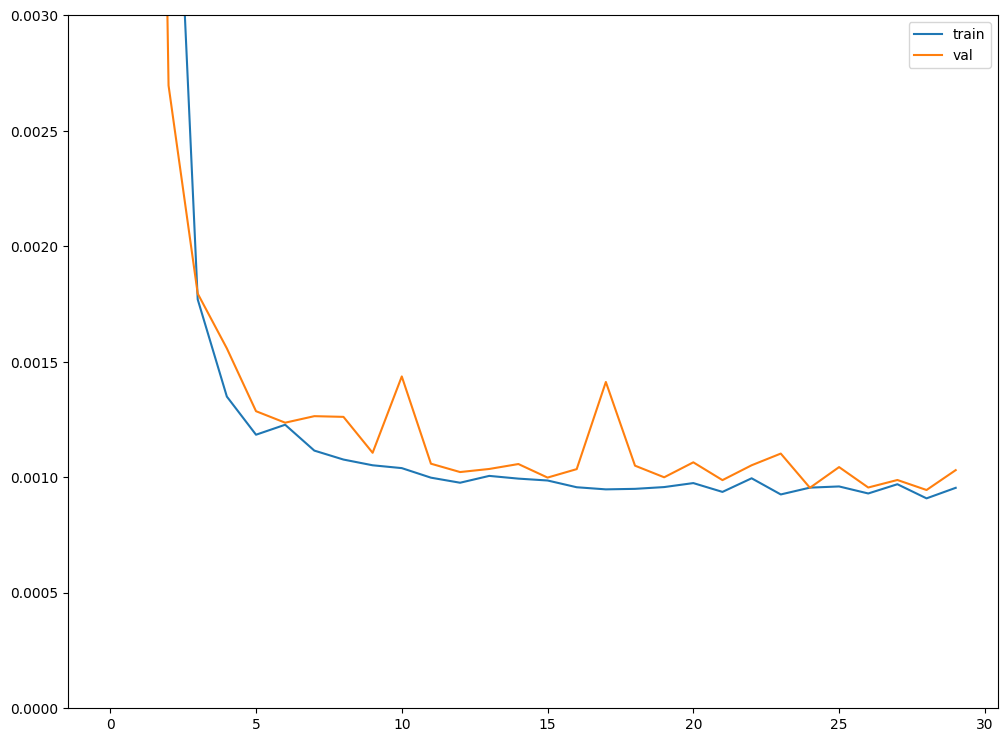

In [781]:
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 9))
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.ylim(0, 0.003)
    plt.legend()
    #plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"))
    plt.show()
    plt.close()
except ImportError:
    pass

Store 4 - past sales shape: (59,)
Store 4 - forecast MAE (SalesLog): 0.17928
Store 4 - forecast RMSE (SalesLog): 0.30786


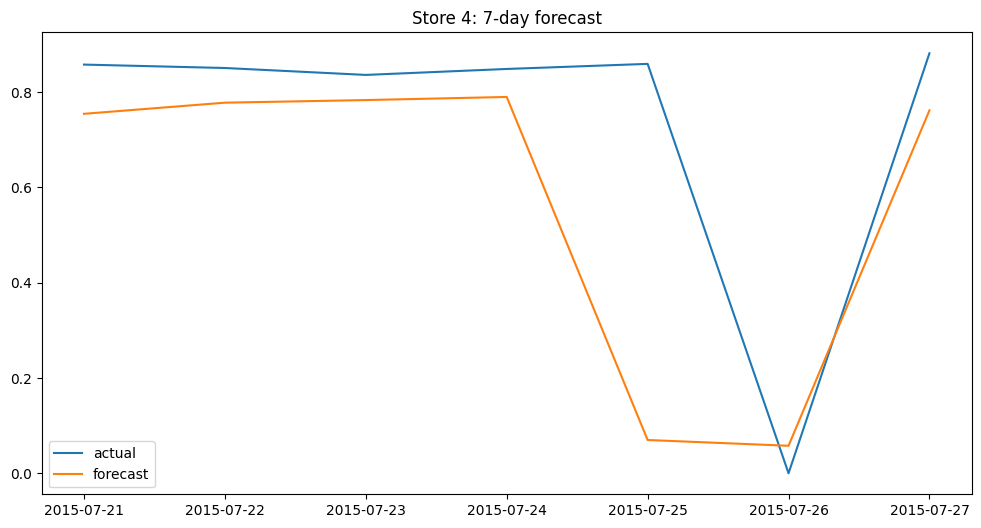

In [786]:
# Test rapido del forecasting su un singolo store usando il modello gia addestrato.
selected_store = 4
N_START = 4

store_history = (
    train_df[train_df["Store"] == selected_store]
    .sort_values("Date")
    .iloc[-(N_STEPS_IN + N_STEPS_OUT) - N_START: -N_START]
    .reset_index(drop=True)
)

if len(store_history) != N_STEPS_IN + N_STEPS_OUT:
    raise ValueError(
        f"Store {selected_store} needs {N_STEPS_IN + N_STEPS_OUT} rows, "
        f"but only {len(store_history)} are available"
    )

past_window = store_history.iloc[:N_STEPS_IN]
future_window = store_history.iloc[N_STEPS_IN:]

# Le vendite storiche sono disponibili nel primo intervallo per il controllo.
past_sales = past_window["SalesLog"].to_numpy()

# Il modello riceve le stesse feature usate durante il training.
pred_X = past_window[feature_cols].to_numpy().reshape(1, N_STEPS_IN, n_features)
pred_future_features = future_window[feature_cols].to_numpy().reshape(1, N_STEPS_OUT, n_features)

preds = predict_regressor(model, pred_X, pred_future_features).ravel()
actual = future_window["SalesLog"].to_numpy()

store_mae = np.mean(np.abs(preds - actual))
store_rmse = np.sqrt(np.mean((preds - actual) ** 2))
print(f"Store {selected_store} - past sales shape: {past_sales.shape}")
print(f"Store {selected_store} - forecast MAE (SalesLog): {store_mae:.5f}")
print(f"Store {selected_store} - forecast RMSE (SalesLog): {store_rmse:.5f}")

plt.figure(figsize=(12, 6))
plt.plot(future_window["Date"], actual, label="actual")
plt.plot(future_window["Date"], preds, label="forecast")
plt.title(f"Store {selected_store}: {N_STEPS_OUT}-day forecast")
plt.legend()
plt.show()